# One Line or Three? Single vs Multiple Checkout Queues

Three clerks. Customers arrive at random (exponential inter-arrival times) and take 1-5 minutes (uniform) to
check out. Compare
- **single queue**: one line; the person at the front goes to the next free clerk
- **multiple queues**: one line per clerk; arriving customers join the shortest line and stay in it

Both layouts see exactly the same customers in every simulation. The simulation code is in
`checkout_queues/clerks.py`.

Three clerks averaging 3 minutes per customer can serve 1 customer per minute. Arrival rates above that are
overloaded: the lines grow for as long as customers keep coming, so their waits depend on how many customers are
simulated.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))  # project root, so checkout_queues imports without installing
from checkout_queues import clerks

## One detailed example

200 customers arriving at 1 per minute.

In [2]:
arrivals, service = clerks.generate_customers(200, arrival_rate=1.0, rng=42)
example = pd.DataFrame({
    "single queue": clerks.wait_stats(arrivals, service, clerks.single_queue(arrivals, service)),
    "multiple queues": clerks.wait_stats(arrivals, service, clerks.multiple_queues(arrivals, service, rng=42)),
})
example.round(2)

,single queue,multiple queues
avg_wait,10.10,10.54
median_wait,11.06,11.18
std_wait,4.27,4.71
max_wait,18.06,20.51
avg_total,13.09,13.53
throughput,0.96,0.96


## Many simulations across loads

100 simulations of 500 customers at each arrival rate; the table and plots show the averages over simulations.

In [3]:
rates = [0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.5]
runs = pd.concat([clerks.compare(num_customers=500, num_simulations=100, arrival_rate=r, seed=i)
                  for i, r in enumerate(rates)])
summary = runs.groupby(["arrival_rate", "layout"])[["avg_wait", "avg_total", "max_wait", "std_wait"]].mean()
summary.unstack("layout").round(2)

avg_wait                    avg_total               \
layout       multiple queues single queue multiple queues single queue   
arrival_rate                                                             
0.8                     2.14         1.88            5.13         4.87   
0.9                     4.60         4.32            7.59         7.31   
1.0                    11.81        11.45           14.82        14.45   
1.1                    26.91        26.63           29.91        29.63   
1.2                    44.51        44.25           47.51        47.25   
1.3                    59.05        58.85           62.05        61.86   
1.5                    84.01        83.84           87.01        86.85   

                    max_wait                     std_wait               
layout       multiple queues single queue multiple queues single queue  
arrival_rate                                                            
0.8                    13.15        10.73            2.63         2.33  
0.9                    19.00        15.99            4.28         4.00  
1.0                    32.93        28.84            8.04         7.72  
1.1                    58.63        53.74           15.04        14.73  
1.2                    94.04        88.00           25.40        25.11  
1.3                   124.93       118.25           34.29        34.01  
1.5                   174.44       167.22           48.38        48.12

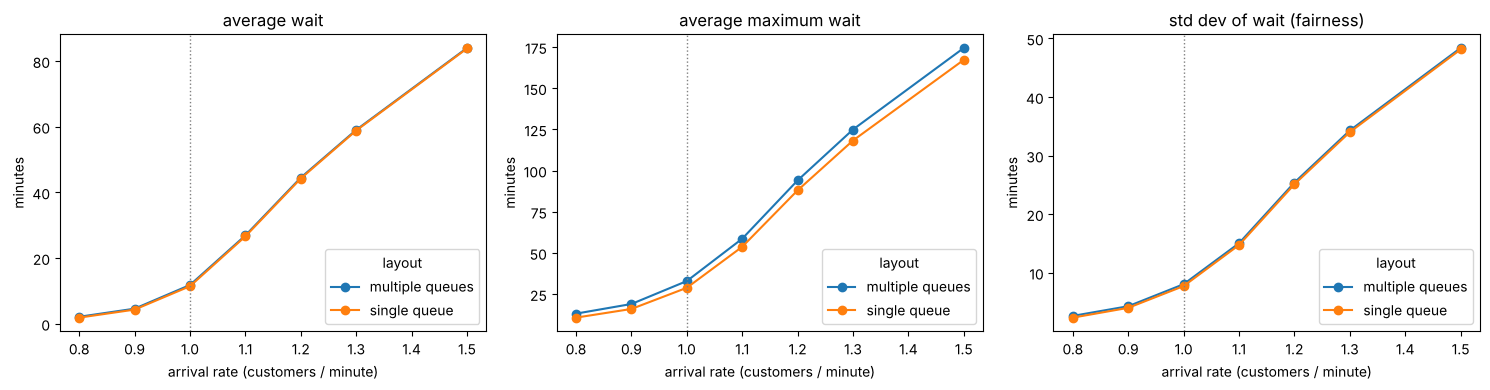

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ["avg_wait", "max_wait", "std_wait"],
                          ["average wait", "average maximum wait", "std dev of wait (fairness)"]):
    summary[col].unstack("layout").plot(ax=ax, marker="o")
    ax.axvline(1.0, color="grey", ls=":", lw=1)
    ax.set_title(title)
    ax.set_xlabel("arrival rate (customers / minute)")
    ax.set_ylabel("minutes")
plt.tight_layout()
plt.show()

In [5]:
pivot = summary["avg_wait"].unstack("layout")
faster = 1 - pivot["single queue"] / pivot["multiple queues"]
print("Single queue reduces the average wait by:")
print(faster.map("{:.0%}".format).to_string())

Single queue reduces the average wait by:
arrival_rate
0.8    12%
0.9     6%
1.0     3%
1.1     1%
1.2     1%
1.3     0%
1.5     0%


The single line is better on every measure, but its edge in *average* wait is modest (about 12% at light load,
vanishing under overload): customers who pick the shortest line already capture most of the benefit of pooling.
The clearer gains are in the worst case and in fairness. With separate lines a customer can get stuck behind a
slow checkout while another line moves, so the longest waits are 10-20% longer and the spread of waits is wider.